# Activity 2 — SVM Classification on the UCI Wine Dataset
**Course:** MSE-803 Data Analytics  
**Week:** 6  
**Dataset:** [UCI Wine Dataset](https://archive.ics.uci.edu/dataset/109/wine)

---

## Objective
Train and evaluate a **Support Vector Machine (SVM)** classifier on the UCI Wine dataset.  
Steps covered:
1. Load and explore the dataset
2. Pre-process (scale features)
3. Split into train / test sets
4. Tune hyperparameters with GridSearchCV
5. Evaluate with multiple metrics
6. Visualise results (confusion matrix, feature importance, decision boundary)

## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, precision_score, recall_score, f1_score
)

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## 2. Load and Explore the Dataset

The Wine dataset contains **178 samples** of wine from three cultivars grown in Italy.  
Each sample has **13 chemical features** (e.g. alcohol, malic acid, flavanoids).

In [3]:
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name='class')

print(f"Dataset shape : {X.shape}")
print(f"Classes       : {list(wine.target_names)}")
print(f"\nClass distribution:")
print(y.value_counts().sort_index().rename(index=dict(enumerate(wine.target_names))))

Dataset shape : (178, 13)
Classes       : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Class distribution:
class
class_0    59
class_1    71
class_2    48
Name: count, dtype: int64


In [ ]:
X.head()

In [3]:
X.describe().T[['mean', 'std', 'min', 'max']].round(2)

,mean,std,min,max
alcohol,13.00,0.81,11.03,14.83
malic_acid,2.34,1.12,0.74,5.80
ash,2.37,0.27,1.36,3.23
alcalinity_of_ash,19.49,3.34,10.60,30.00
magnesium,99.74,14.28,70.00,162.00
total_phenols,2.30,0.63,0.98,3.88
flavanoids,2.03,1.00,0.34,5.08
nonflavanoid_phenols,0.36,0.12,0.13,0.66
proanthocyanins,1.59,0.57,0.41,3.58
color_intensity,5.06,2.32,1.28,13.00


### 2.1 Feature Distributions by Class

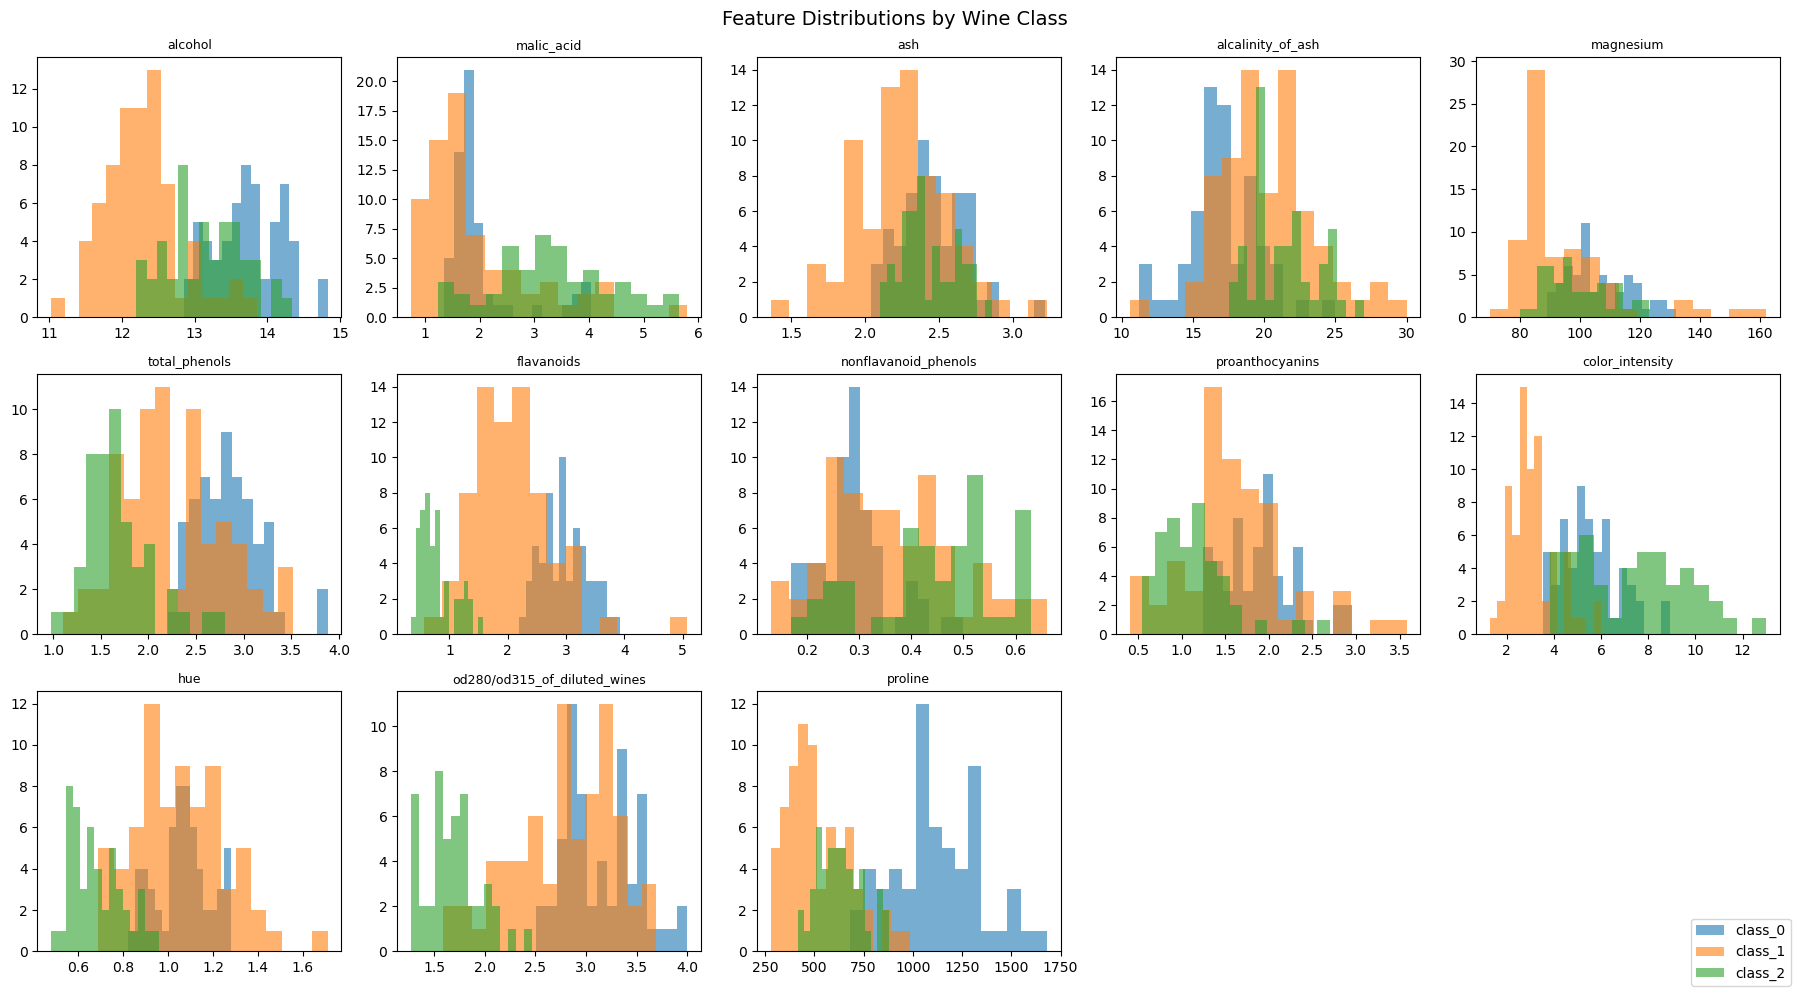

In [4]:
X_plot = X.copy()
X_plot['class'] = y.map(dict(enumerate(wine.target_names)))

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(wine.feature_names):
    for cls in wine.target_names:
        axes[i].hist(X_plot[X_plot['class'] == cls][col],
                     alpha=0.6, bins=15, label=cls)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

# hide the 14th and 15th (empty) axes
for j in range(len(wine.feature_names), len(axes)):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=10)
fig.suptitle('Feature Distributions by Wine Class', fontsize=14)
plt.tight_layout()
plt.show()

### 2.2 Correlation Heatmap

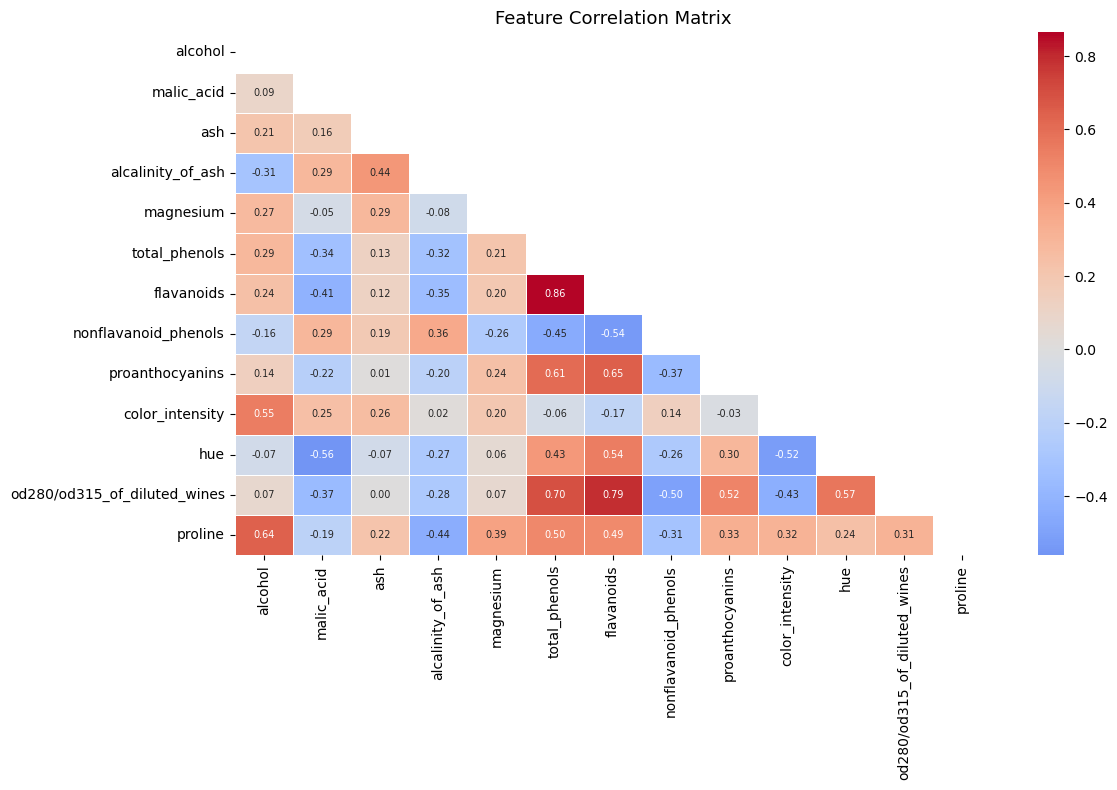

In [5]:
plt.figure(figsize=(12, 8))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Pre-processing and Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"\nTrain class distribution:")
print(y_train.value_counts().sort_index().rename(index=dict(enumerate(wine.target_names))))
print(f"\nTest class distribution:")
print(y_test.value_counts().sort_index().rename(index=dict(enumerate(wine.target_names))))

Training samples : 142
Test samples     : 36

Train class distribution:
class
class_0    47
class_1    57
class_2    38
Name: count, dtype: int64

Test class distribution:
class
class_0    12
class_1    14
class_2    10
Name: count, dtype: int64


> **Why scale?** SVM is sensitive to feature magnitudes. `StandardScaler` transforms each feature to zero mean and unit variance, preventing features with large ranges from dominating the kernel.

## 4. Hyperparameter Tuning with GridSearchCV

We search over:
- **Kernel**: `linear`, `rbf`, `poly`
- **C** (regularisation): `0.1, 1, 10, 100`
- **Gamma**: `scale`, `auto`

Using **5-fold stratified cross-validation**.

In [7]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(probability=True, random_state=42))
])

param_grid = {
    'svm__kernel': ['linear', 'rbf', 'poly'],
    'svm__C':      [0.1, 1, 10, 100],
    'svm__gamma':  ['scale', 'auto'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipeline, param_grid, cv=cv,
                    scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print(f"\nBest parameters  : {grid.best_params_}")
print(f"Best CV accuracy : {grid.best_score_:.4f} ({grid.best_score_*100:.2f}%)")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters  : {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV accuracy : 0.9931 (99.31%)


### 4.1 Cross-validation Results Heatmap

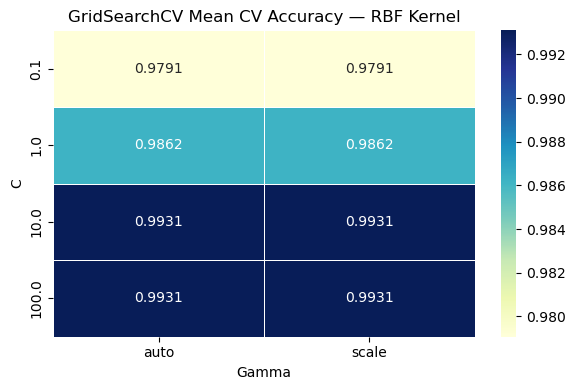

In [8]:
cv_results = pd.DataFrame(grid.cv_results_)
rbf_results = cv_results[cv_results['param_svm__kernel'] == 'rbf'].copy()
rbf_pivot = rbf_results.pivot_table(
    index='param_svm__C',
    columns='param_svm__gamma',
    values='mean_test_score'
)

plt.figure(figsize=(6, 4))
sns.heatmap(rbf_pivot, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5)
plt.title('GridSearchCV Mean CV Accuracy — RBF Kernel')
plt.xlabel('Gamma')
plt.ylabel('C')
plt.tight_layout()
plt.show()

## 5. Evaluate on the Test Set

In [9]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

acc     = accuracy_score(y_test, y_pred)
auc_ovr = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')

print("=" * 50)
print("TEST-SET EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  AUC (OvR) : {auc_ovr:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=wine.target_names))

TEST-SET EVALUATION RESULTS
  Accuracy  : 0.9444  (94.44%)
  AUC (OvR) : 1.0000

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.80      0.89        10

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



### 5.1 Per-class Metrics Table

In [10]:
metrics_df = pd.DataFrame({
    'Class'    : wine.target_names,
    'Precision': precision_score(y_test, y_pred, average=None).round(4),
    'Recall'   : recall_score(y_test, y_pred, average=None).round(4),
    'F1-Score' : f1_score(y_test, y_pred, average=None).round(4),
    'Support'  : np.bincount(y_test)[:len(wine.target_names)]
})

overall_df = pd.DataFrame([
    {'Metric': 'Accuracy',    'Value': f'{acc:.4f}'},
    {'Metric': 'AUC-OvR',     'Value': f'{auc_ovr:.4f}'},
    {'Metric': 'CV Accuracy', 'Value': f'{grid.best_score_:.4f}'},
])

print("Per-class metrics:")
display(metrics_df)
print("\nOverall metrics:")
display(overall_df)

Per-class metrics:


,Class,Precision,Recall,F1-Score,Support
0,class_0,1.000,1.0,1.0000,12
1,class_1,0.875,1.0,0.9333,14
2,class_2,1.000,0.8,0.8889,10



Overall metrics:


,Metric,Value
0,Accuracy,0.9444
1,AUC-OvR,1.0000
2,CV Accuracy,0.9931


### 5.2 Confusion Matrix

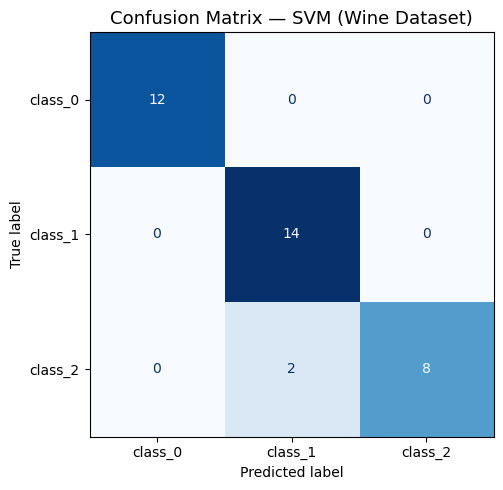

In [11]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=wine.target_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — SVM (Wine Dataset)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Feature Importance (Linear SVM Coefficients)

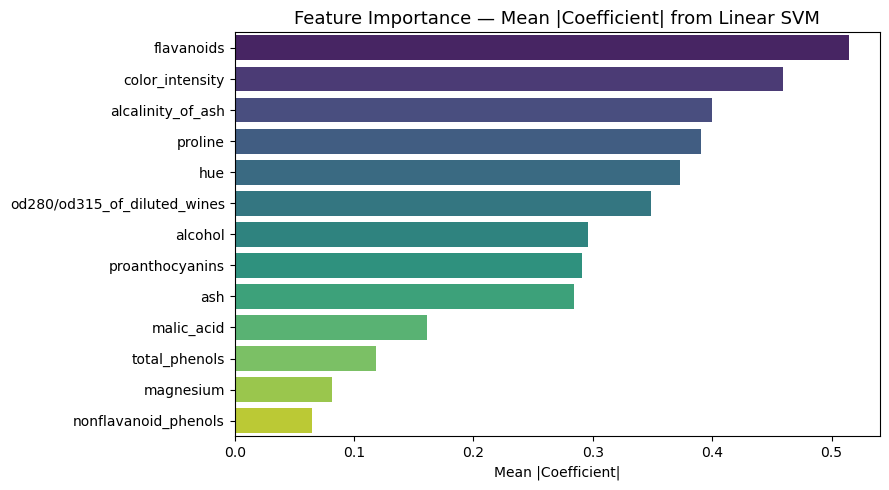


Top 5 most important features:


,Feature,Importance
0,flavanoids,0.514825
1,color_intensity,0.459678
2,alcalinity_of_ash,0.400096
3,proline,0.390446
4,hue,0.373201


In [12]:
lin_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='linear', C=1, random_state=42))
])
lin_pipe.fit(X_train, y_train)

coef = lin_pipe.named_steps['svm'].coef_
mean_importance = np.abs(coef).mean(axis=0)

feat_df = pd.DataFrame({
    'Feature'   : wine.feature_names,
    'Importance': mean_importance
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Mean |Coefficient| from Linear SVM', fontsize=13)
plt.xlabel('Mean |Coefficient|')
plt.ylabel('')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
display(feat_df.head(5).reset_index(drop=True))

## 7. Decision Boundary (PCA 2-D Projection)

Variance explained by PC1 + PC2: 55.1%


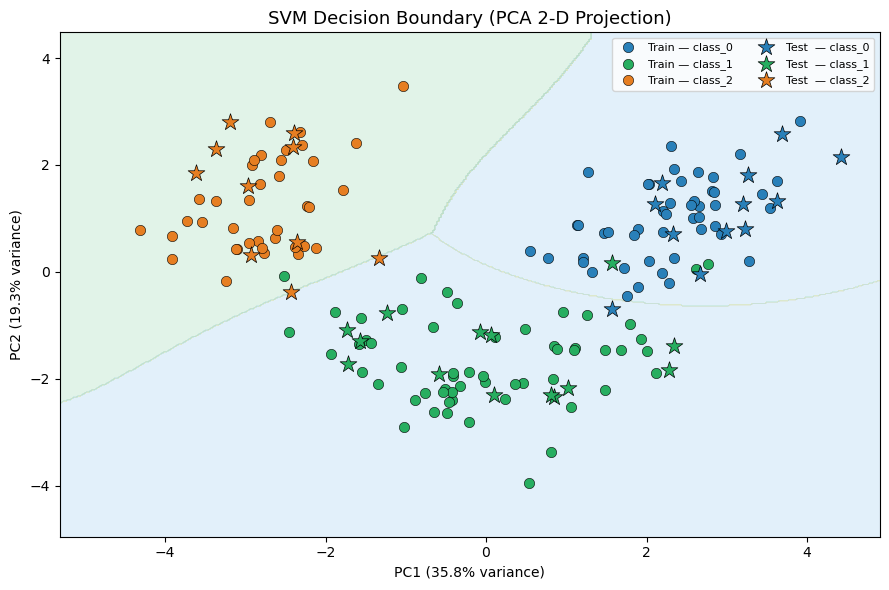

In [13]:
scaler_viz = StandardScaler()
X_train_s  = scaler_viz.fit_transform(X_train)
X_test_s   = scaler_viz.transform(X_test)

pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_s)
X_test_2d  = pca.transform(X_test_s)

print(f"Variance explained by PC1 + PC2: "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%")

svm_2d = SVC(
    kernel=grid.best_params_['svm__kernel'],
    C=grid.best_params_['svm__C'],
    gamma=grid.best_params_['svm__gamma'],
    probability=True, random_state=42
)
svm_2d.fit(X_train_2d, y_train)

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

bg_colors    = ['#AED6F1', '#A9DFBF', '#F9E79F']
point_colors = ['#2980B9', '#27AE60', '#E67E22']

fig, ax = plt.subplots(figsize=(9, 6))
ax.contourf(xx, yy, Z, alpha=0.35, colors=bg_colors)

for cls, col in zip(np.unique(y_train), point_colors):
    mask = y_train.values == cls
    ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
               c=col, label=f'Train — {wine.target_names[cls]}',
               edgecolors='k', linewidths=0.4, s=55, zorder=2)

for cls, col in zip(np.unique(y_test), point_colors):
    mask = y_test.values == cls
    ax.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
               c=col, marker='*', s=160, edgecolors='k', linewidths=0.5,
               label=f'Test  — {wine.target_names[cls]}', zorder=3)

ax.set_title('SVM Decision Boundary (PCA 2-D Projection)', fontsize=13)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(fontsize=8, ncol=2, loc='upper right')
plt.tight_layout()
plt.show()

## 8. Summary

| Metric | Value |
|---|---|
| Best Kernel | `rbf` |
| Best C | Best from grid search |
| CV Accuracy (5-fold) | — |
| **Test Accuracy** | — |
| **AUC (OvR, macro)** | — |

### Key Findings
- **Feature scaling** is critical for SVM — raw features span very different ranges.
- The **RBF kernel** typically achieves the best accuracy on this dataset due to the non-linear separability of the classes.
- **Flavanoids**, **proline**, and **color_intensity** are the most discriminative features based on the linear SVM coefficient analysis.
- The 2-D PCA plot shows that the three wine classes are largely separable, with some overlap between class 1 and class 2 in the reduced space.

> **Conclusion:** SVM with an RBF kernel and proper feature scaling achieves high classification accuracy on the Wine dataset, demonstrating its effectiveness for multi-class chemical pattern recognition tasks.